# Pha P'.0 — Ablation "dequantization" cổ điển (trước khi vào lượng tử)

Mục đích (xem `docs/NHIP2_GUIDE.md` mục 1–2): tách bạch "lợi ích từ dạng hàm
Fourier" (Schuld, Sweke & Meyer, *Phys. Rev. A* 103, 032430, 2021 — mạch
data re-uploading tương đương 1 chuỗi Fourier riêng phần của dữ liệu) khỏi
"lợi ích từ bản chất lượng tử" (entanglement, Hilbert space lớn), TRƯỚC khi
cài PennyLane/viết mạch lượng tử thật.

`FourierFeatureStatisticsNetwork` (`src/pqrst/estimators/classical_fourier.py`)
là 1 mô hình HOÀN TOÀN CỔ ĐIỂN, chỉ 41 tham số (encode tuyến tính học được +
đọc ra bằng tổ hợp sin/cos ở các hoà âm nguyên) — cùng bậc độ lớn với 1 mạch
lượng tử nhỏ dự kiến (6–8 qubit × 3–5 lớp).

**Không tính lại KSG** — tái dùng đúng số liệu KSG đã có trong
`phase_r_grid_summary.csv`/`phase_r2_periodic_grid_summary.csv`, chỉ train +
đánh giá thêm đúng 1 estimator mới trên đúng tập test đã đóng băng.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import yaml, time, numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig, AmortizedTEEstimator
from pqrst.estimators.classical_fourier import FourierFeatureStatisticsNetwork
from pqrst.evaluation.grid import evaluate_estimators_on_grid, summarize_grid

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE / 'configs' / 'mine' / 'amortized.yaml', encoding='utf-8'))
train_cfg = cfg['train']
N_HARMONICS = 4

n_params_fourier = sum(p.numel() for p in FourierFeatureStatisticsNetwork(N_HARMONICS).parameters())
print(f'FourierFeatureStatisticsNetwork: {n_params_fourier} tham so (n_harmonics={N_HARMONICS})')

FourierFeatureStatisticsNetwork: 41 tham so (n_harmonics=4)


## 1. Dữ liệu tuyến tính (VAR) — train + đánh giá

In [2]:
corpus_dir = BASE / 'data' / 'interim' / 'synthetic_corpus'
train_windows = load_corpus(str(corpus_dir / 'train.npz'))
val_windows = load_corpus(str(corpus_dir / 'val.npz'))
test_windows_linear = load_corpus(str(corpus_dir / 'test.npz'))
print(f'Linear: train={len(train_windows)}, val={len(val_windows)}, test={len(test_windows_linear)}')

Linear: train=22950, val=4050, test=18000


In [3]:
config_fourier = AmortizedTrainConfig(
    learning_rate=train_cfg['learning_rate'],
    windows_per_batch=train_cfg['windows_per_batch'],
    max_epochs=train_cfg['max_epochs'],
    patience=train_cfg['patience'],
    eval_n_shuffles=train_cfg['eval_n_shuffles'],
    final_estimate_last_k_epochs=train_cfg['final_estimate_last_k_epochs'],
    seed=train_cfg['seed'],
    standardize=False,  # khop dung cach phi_amortized.pt/phi_amortized_periodic.pt da train,
                         # de so sanh apples-to-apples voi phase_r_grid_summary.csv
)

start = time.time()
est_fourier_linear, hist_fourier_linear = train_amortized(
    train_windows, val_windows, config_fourier,
    model_factory=lambda: FourierFeatureStatisticsNetwork(N_HARMONICS),
)
print(f'Time: {time.time()-start:.1f}s, epochs run: {len(hist_fourier_linear["train_loss_history"])}, '
      f'final_val_loss={hist_fourier_linear["final_val_loss"]:.4f}')

Time: 4166.4s, epochs run: 54, final_val_loss=0.0000


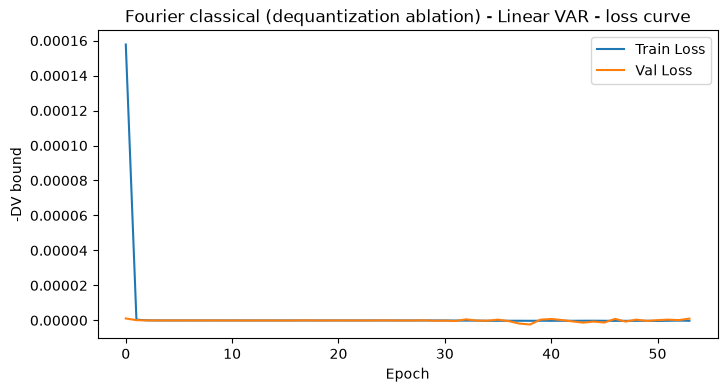

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(hist_fourier_linear['train_loss_history'], label='Train Loss')
plt.plot(hist_fourier_linear['val_loss_history'], label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('-DV bound'); plt.legend()
plt.title('Fourier classical (dequantization ablation) - Linear VAR - loss curve')
out_dir = BASE / 'results' / 'figures'; out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'phase_p2_fourier_linear_loss.png', dpi=100)
plt.show()

In [5]:
raw_fourier_linear = evaluate_estimators_on_grid(
    {'Fourier_classical': est_fourier_linear}, test_windows_linear, progress=True)
summary_fourier_linear = summarize_grid(raw_fourier_linear)
summary_fourier_linear.head()

Evaluating windows: 100%|██████████| 18000/18000 [02:09<00:00, 139.06it/s]


,config_name,coupling_c,noise_std,n_samples,estimator,n_valid,n_failed,bias,variance,mse,ci_low,ci_high
0,c_0.0_noise_0.3,0.0,0.3,10,Fourier_classical,200,0,4.616737e-06,2.903244e-13,2.160314e-11,0.000005,0.000005
1,c_0.0_noise_0.3,0.0,0.3,20,Fourier_classical,200,0,3.814697e-06,0.000000e+00,1.455192e-11,0.000004,0.000004
2,c_0.0_noise_0.3,0.0,0.3,30,Fourier_classical,200,0,2.315521e-06,1.083547e-12,6.439768e-12,0.000002,0.000002
3,c_0.0_noise_0.3,0.0,0.3,50,Fourier_classical,200,0,2.220446e-16,0.000000e+00,4.930381e-32,0.000000,0.000000
4,c_0.0_noise_0.3,0.0,0.3,100,Fourier_classical,200,0,4.666328e-06,1.297562e-12,2.306570e-11,0.000005,0.000005


## 2. Dữ liệu phi tuyến (periodic coupling) — train + đánh giá

In [6]:
corpus_dir_periodic = BASE / 'data' / 'interim' / 'synthetic_corpus_periodic'
train_windows_p = load_corpus(str(corpus_dir_periodic / 'train.npz'))
val_windows_p = load_corpus(str(corpus_dir_periodic / 'val.npz'))
test_windows_periodic = load_corpus(str(corpus_dir_periodic / 'test.npz'))
print(f'Periodic: train={len(train_windows_p)}, val={len(val_windows_p)}, test={len(test_windows_periodic)}')

Periodic: train=8160, val=1440, test=7200


In [7]:
start = time.time()
est_fourier_periodic, hist_fourier_periodic = train_amortized(
    train_windows_p, val_windows_p, config_fourier,
    model_factory=lambda: FourierFeatureStatisticsNetwork(N_HARMONICS),
)
print(f'Time: {time.time()-start:.1f}s, epochs run: {len(hist_fourier_periodic["train_loss_history"])}, '
      f'final_val_loss={hist_fourier_periodic["final_val_loss"]:.4f}')

Time: 1996.8s, epochs run: 77, final_val_loss=-0.0000


In [8]:
raw_fourier_periodic = evaluate_estimators_on_grid(
    {'Fourier_classical': est_fourier_periodic}, test_windows_periodic, progress=True)
summary_fourier_periodic = summarize_grid(raw_fourier_periodic)
summary_fourier_periodic.head()

Evaluating windows: 100%|██████████| 7200/7200 [00:52<00:00, 137.42it/s]


,config_name,coupling_c,noise_std,n_samples,estimator,n_valid,n_failed,bias,variance,mse,ci_low,ci_high
0,periodic_k_0.0_noise_0.1,0.0,0.1,10,Fourier_classical,150,0,-9.059906e-08,3.879315e-13,3.935535e-13,-1.902745e-07,9.076339e-09
1,periodic_k_0.0_noise_0.1,0.0,0.1,20,Fourier_classical,150,0,-4.291534e-08,2.454949e-13,2.457000e-13,-1.222078e-07,3.637708e-08
2,periodic_k_0.0_noise_0.1,0.0,0.1,30,Fourier_classical,150,0,-6.262461e-08,4.273751e-13,4.284478e-13,-1.672447e-07,4.199547e-08
3,periodic_k_0.0_noise_0.1,0.0,0.1,50,Fourier_classical,150,0,-1.773834e-07,3.134436e-13,3.428189e-13,-2.669797e-07,-8.778711e-08
4,periodic_k_0.0_noise_0.1,0.0,0.1,100,Fourier_classical,150,0,-4.816055e-07,2.826377e-13,5.126973e-13,-5.666851e-07,-3.965259e-07


## 3. Gộp với KSG/Amortized đã có sẵn (KHÔNG tính lại) + so sánh

In [9]:
tables_dir = BASE / 'results' / 'tables'

df_linear_existing = pd.read_csv(tables_dir / 'phase_r_grid_summary.csv')
df_linear_existing = df_linear_existing[df_linear_existing['estimator'].isin(['KSG', 'Amortized'])].copy()
summary_fourier_linear['estimator'] = 'Fourier_classical'
df_linear = pd.concat([df_linear_existing, summary_fourier_linear], ignore_index=True)
df_linear['dataset'] = 'Linear VAR'

df_periodic_existing = pd.read_csv(tables_dir / 'phase_r2_periodic_grid_summary.csv')
df_periodic_existing = df_periodic_existing[df_periodic_existing['estimator'].isin(['KSG', 'Amortized'])].copy()
summary_fourier_periodic['estimator'] = 'Fourier_classical'
df_periodic = pd.concat([df_periodic_existing, summary_fourier_periodic], ignore_index=True)
df_periodic['dataset'] = 'Periodic Coupling'

df_all = pd.concat([df_linear, df_periodic], ignore_index=True)
df_all.to_csv(tables_dir / 'phase_p2_dequantization_summary.csv', index=False)
print(f'Da luu {len(df_all)} dong -> phase_p2_dequantization_summary.csv')

Da luu 414 dong -> phase_p2_dequantization_summary.csv


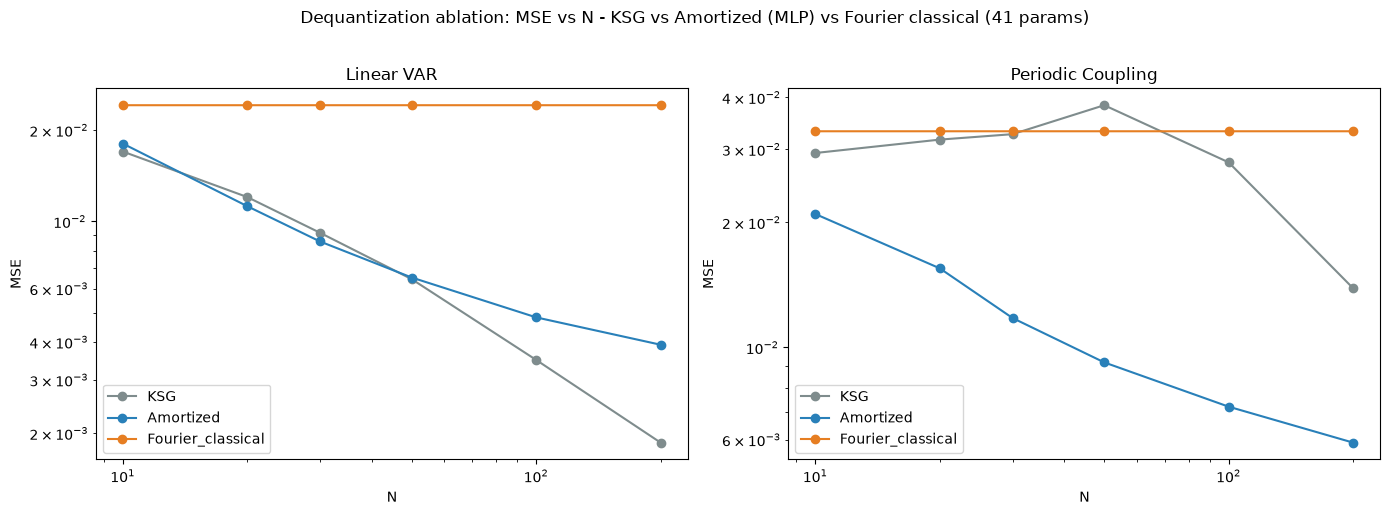

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'KSG': '#7f8c8d', 'Amortized': '#2980b9', 'Fourier_classical': '#e67e22'}
for ax, ds in zip(axes, ['Linear VAR', 'Periodic Coupling']):
    sub = df_all[df_all['dataset'] == ds]
    for est, color in colors.items():
        g = sub[sub['estimator'] == est].groupby('n_samples')['mse'].mean().reset_index()
        ax.plot(g['n_samples'], g['mse'], marker='o', label=est, color=color)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('N'); ax.set_ylabel('MSE'); ax.set_title(ds); ax.legend()
fig.suptitle('Dequantization ablation: MSE vs N - KSG vs Amortized (MLP) vs Fourier classical (41 params)', y=1.02)
plt.tight_layout()
plt.savefig(out_dir / 'phase_p2_dequantization_mse.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Kết luận (tính từ số liệu, không đoán trước)

In [11]:
for ds in ['Linear VAR', 'Periodic Coupling']:
    sub = df_all[df_all['dataset'] == ds]
    piv = sub.groupby(['n_samples', 'estimator'])['mse'].mean().unstack()
    n_fourier_beats_amortized = int((piv['Fourier_classical'] < piv['Amortized']).sum())
    n_total = len(piv)
    print(f'=== {ds} ===')
    print(piv)
    print(f'-> Fourier_classical (41 tham so) thang Amortized (MLP, 25473 tham so) ve MSE '
          f'o {n_fourier_beats_amortized}/{n_total} gia tri N.')
    print()

print('Doc ket qua theo docs/NHIP2_GUIDE.md muc 1:')
print('- Neu Fourier_classical thang/ngang Amortized: tin hieu tot co the den tu DANG HAM')
print('  Fourier, chua chac can luong tu thuc - van dang lam luong tu nhung phai neu ro dieu nay.')
print('- Neu Fourier_classical thua ro: cau chuyen can luong tu thuc (entanglement) manh hon.')

=== Linear VAR ===
estimator  Amortized  Fourier_classical       KSG
n_samples                                        
10          0.018054           0.024164  0.016995
20          0.011221           0.024164  0.012027
30          0.008582           0.024164  0.009169
50          0.006527           0.024165  0.006445
100         0.004823           0.024164  0.003490
200         0.003917           0.024164  0.001862
-> Fourier_classical (41 tham so) thang Amortized (MLP, 25473 tham so) ve MSE o 0/6 gia tri N.

=== Periodic Coupling ===
estimator  Amortized  Fourier_classical       KSG
n_samples                                        
10          0.020952           0.033146  0.029384
20          0.015506           0.033146  0.031648
30          0.011773           0.033146  0.032616
50          0.009206           0.033146  0.038296
100         0.007202           0.033146  0.027897
200         0.005901           0.033146  0.013885
-> Fourier_classical (41 tham so) thang Amortized (MLP, 254